## SmartCart aims to build an using intelligent customer segmentation unsupervised machine learning
 

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from kneed import KneeLocator

from sklearn.decomposition import PCA

In [54]:
df = pd.read_csv("smartcart_customers.csv")

In [55]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [56]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Handeling Missing values

In [57]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature Engineering

### Basically we want to convert the Date,age,joining date into a numerical col

In [58]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [59]:
df["Age"] = df['Year_Birth'].max() - df["Year_Birth"]

In [60]:
# we will convert the date of coustomer to coustomer joining days

# we convert the date into the fomate suported by pandas
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst = True)

refrence_date = df["Dt_Customer"].max()

df["Coustomer_Tenure_Days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [61]:
df["Education"].value_counts()
df["Education"] = df["Education"].replace({
    "Graduation":"Graduate" , 
    "PhD":"PostGraduate",
    "Master":"PostGraduate",
    "2n Cycle":"UnderGraduate",
    "Basic":"UnderGraduate"
})

In [62]:
# Marital_Status

df["Marital_Status"].value_counts()
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner" , 
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Alone":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [63]:
# combining the childrens

df["Childrens"] = df["Kidhome"] + df["Teenhome"]

In [64]:
# since we have to do coustomer segmentation we will add all the spending for each coutomers

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [65]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Coustomer_Tenure_Days,Living_With,Childrens,Total_Spending
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,39,663,Alone,0,1617
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,42,113,Alone,2,27
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,31,312,Partner,0,776
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,12,139,Partner,1,53
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,15,161,Partner,1,422


## Drop the coloumns

In [68]:
cols = ["ID" , "Year_Birth" , "Marital_Status" , "Kidhome" ,"Teenhome" ,"Dt_Customer"]
spending_cols = ["MntWines","MntFruits" , "MntMeatProducts", "MntFishProducts" ,"MntSweetProducts" ,"MntGoldProds"]

col_to_drop = cols + spending_cols
Cleaned_df = df.drop(columns = col_to_drop)
Cleaned_df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Coustomer_Tenure_Days,Living_With,Childrens,Total_Spending
0,Graduate,58138.0,58,3,8,10,4,7,0,1,39,663,Alone,0,1617
1,Graduate,46344.0,38,2,1,1,2,5,0,0,42,113,Alone,2,27
2,Graduate,71613.0,26,1,8,2,10,4,0,0,31,312,Partner,0,776
3,Graduate,26646.0,26,2,2,0,4,6,0,0,12,139,Partner,1,53
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,15,161,Partner,1,422


In [70]:
Cleaned_df.shape

(2240, 15)

## OutLier Detection

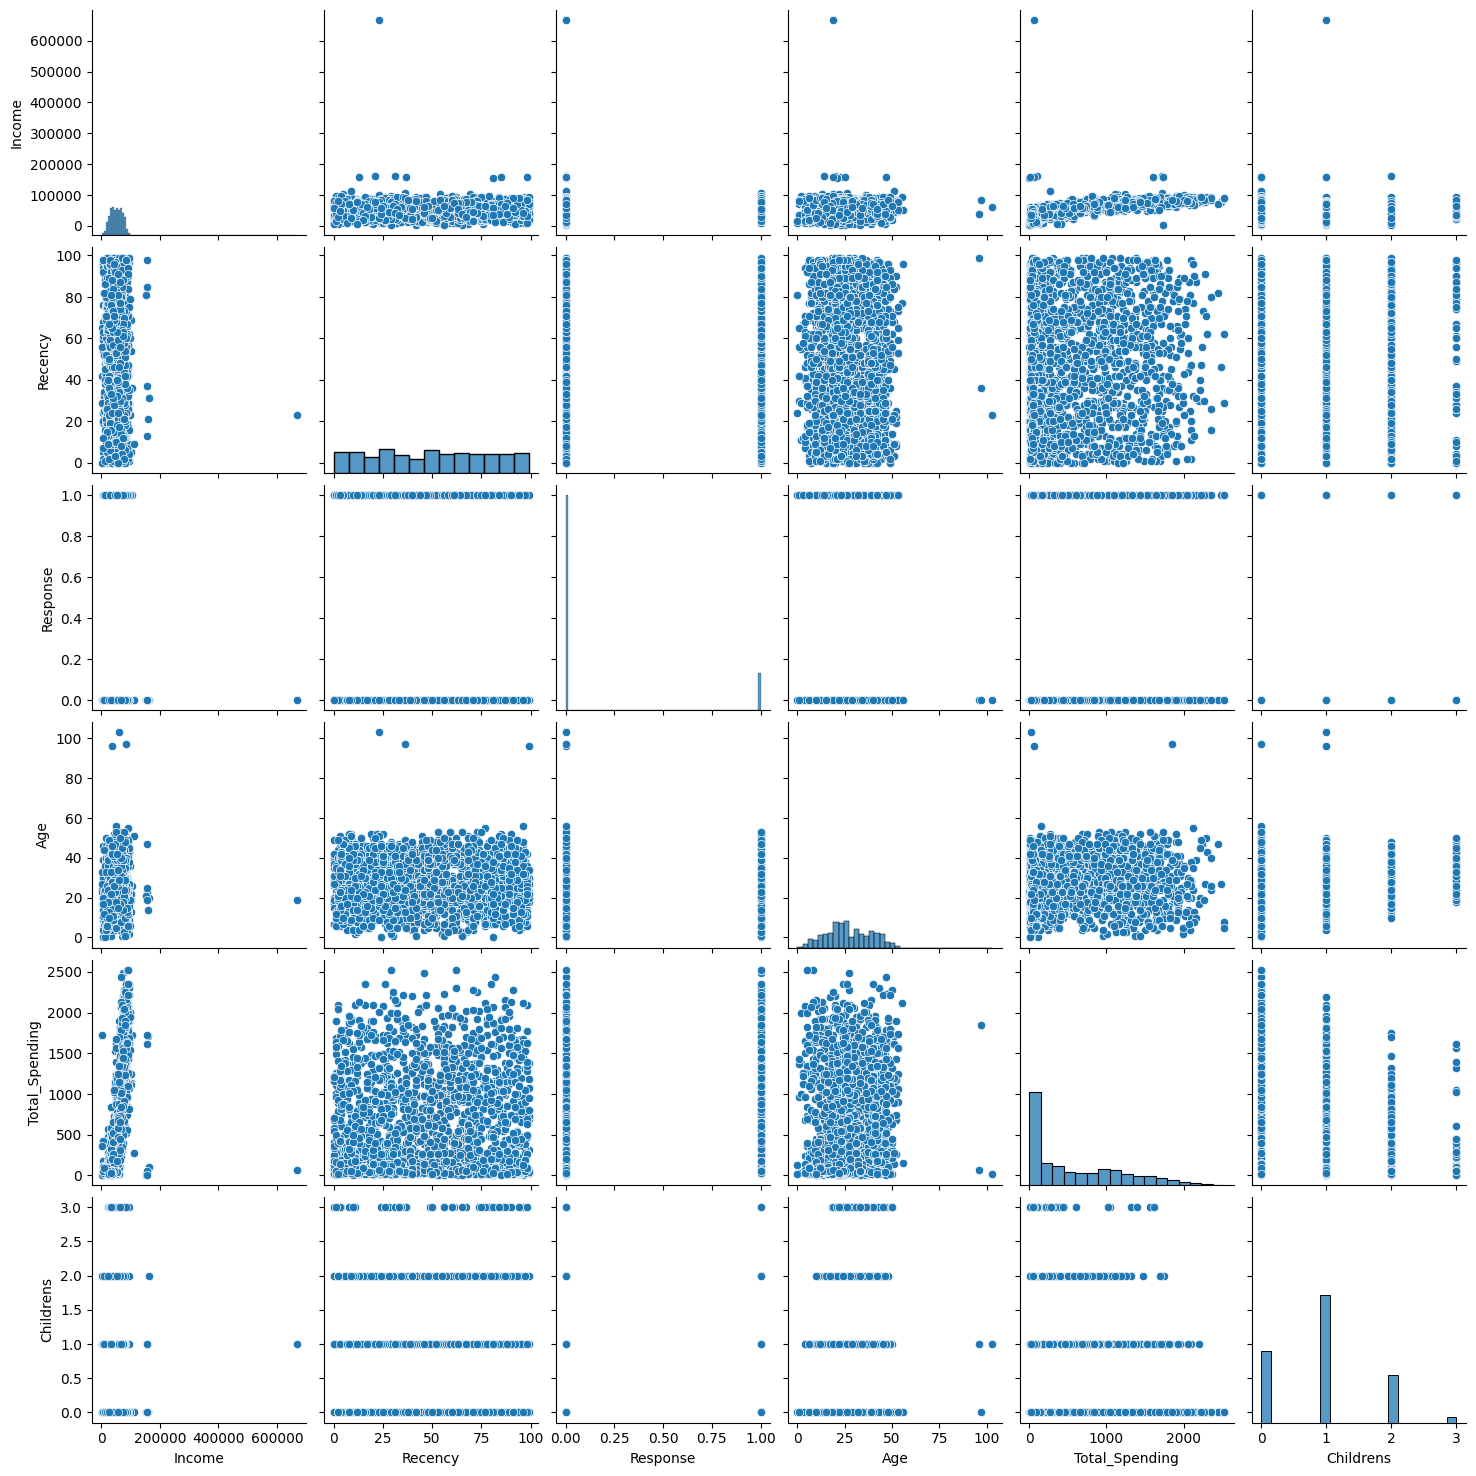

In [74]:
# for outlier detection we will use the pair plot 

cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Childrens"]

sns.pairplot(Cleaned_df[cols])

In [75]:
#  outliers : 
# income > 600000 , age > 90

print("length with outliers :" , len(Cleaned_df))
Cleaned_df = Cleaned_df[(Cleaned_df["Age"] < 90) ]
Cleaned_df = Cleaned_df[(Cleaned_df["Income"] < 600000)]


print("length without outliers :" , len(Cleaned_df))

length with outliers : 2240
length without outliers : 2236


<Axes: >

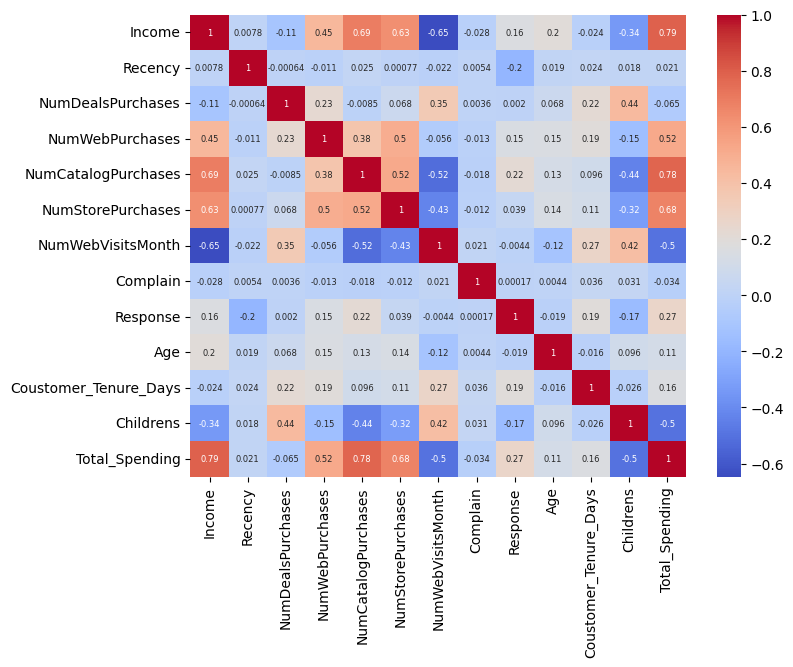

In [79]:
# now we will make a correlation Matrix which help us to visulise the most related feature which will help us in finding the patterns further

corr = Cleaned_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

# Encoding

In [86]:
ohe = OneHotEncoder()

cat_col = ["Education" , "Living_With"]
encoded_col = ohe.fit_transform(Cleaned_df[cat_col]).toarray()
encoded_col

array([[1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1.]], shape=(2236, 5))

In [89]:
# conveting  array to dataframe

encoded_df = pd.DataFrame(encoded_col , columns = ohe.get_feature_names_out(cat_col) , index = Cleaned_df.index)

In [102]:
df_encoded = pd.concat([Cleaned_df.drop(columns = cat_col) , encoded_df] , axis = 1)

In [104]:
df_encoded.shape

(2236, 18)

## scaling

In [107]:
scaler = StandardScaler()
X = df_encoded
X_scaled = scaler.fit_transform(X)

## Finding the value of k and traning the models

In [112]:
# Finding the value of k by elbow method

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [114]:
# this just explain ki kitna info cover kra hai 23+11+10 = 44 whihh is not good but we can use this
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

## now we will find the K value

In [116]:
wcss = []
for k in range(1,11):
    K_means = KMeans(n_clusters = k)
    K_means.fit_predict(X_pca)
    wcss.append(K_means.inertia_)

In [117]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [118]:
optimal_k

np.int64(4)

## Now we got the k value no we will train the algo given k =4 